In [10]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

from sklearn.preprocessing import LabelEncoder

import matplotlib.pyplot as plt

In [11]:
import os

print(os.listdir())

['.config', 'GUIDE_Test.csv', 'sample_data']


In [9]:
data = pd.read_csv("GUIDE_Test.csv")

print(data.shape)
data.head()

(1527080, 46)


,Id,OrgId,IncidentId,AlertId,Timestamp,DetectorId,AlertTitle,Category,MitreTechniques,IncidentGrade,...,Roles,OSFamily,OSVersion,AntispamDirection,SuspicionLevel,LastVerdict,CountryCode,State,City,Usage
0,1245540519230,657,11767,87199,2024-06-04T22:56:27.000Z,524,563,LateralMovement,T1021;T1047;T1105;T1569.002,BenignPositive,...,NaN,5.0,66.0,NaN,Suspicious,Suspicious,242.0,1445.0,10630.0,Private
1,1400159342154,3,91158,632273,2024-06-03T12:58:26.000Z,2,2,CommandAndControl,NaN,BenignPositive,...,NaN,0.0,0.0,NaN,Suspicious,Suspicious,242.0,1445.0,10630.0,Public
2,1279900255923,145,32247,131719,2024-06-08T03:20:49.000Z,2932,10807,LateralMovement,T1021;T1027.002;T1027.005;T1105,BenignPositive,...,NaN,5.0,66.0,NaN,Suspicious,Suspicious,242.0,1445.0,10630.0,Public
3,60129547292,222,15294,917686,2024-06-12T12:07:31.000Z,0,0,InitialAccess,T1078;T1078.004,FalsePositive,...,NaN,5.0,66.0,NaN,NaN,NaN,242.0,1445.0,10630.0,Public
4,515396080539,363,7615,5944,2024-06-06T17:42:05.000Z,27,18,Discovery,T1087;T1087.002,BenignPositive,...,Suspicious,5.0,66.0,NaN,NaN,NaN,242.0,1445.0,10630.0,Public


In [12]:
data = data[
    [
        "Category",
        "SuspicionLevel",
        "LastVerdict",
        "IncidentGrade"
    ]
]

data.head()

,Category,SuspicionLevel,LastVerdict,IncidentGrade
0,LateralMovement,Suspicious,Suspicious,BenignPositive
1,CommandAndControl,Suspicious,Suspicious,BenignPositive
2,LateralMovement,Suspicious,Suspicious,BenignPositive
3,InitialAccess,NaN,NaN,FalsePositive
4,Discovery,NaN,NaN,BenignPositive


In [13]:
print(data.isnull().sum())

Category                0
SuspicionLevel    1288292
LastVerdict       1161652
IncidentGrade           0
dtype: int64


In [15]:
data["SuspicionLevel"] = data["SuspicionLevel"].fillna("Unknown")

data["LastVerdict"] = data["LastVerdict"].fillna("Unknown")

In [16]:
priority_map = {
    "TruePositive": "Critical",
    "BenignPositive": "Medium",
    "FalsePositive": "Low"
}

data["Priority"] = data["IncidentGrade"].map(priority_map)

data.head()

,Category,SuspicionLevel,LastVerdict,IncidentGrade,Priority
0,LateralMovement,Suspicious,Suspicious,BenignPositive,Medium
1,CommandAndControl,Suspicious,Suspicious,BenignPositive,Medium
2,LateralMovement,Suspicious,Suspicious,BenignPositive,Medium
3,InitialAccess,Unknown,Unknown,FalsePositive,Low
4,Discovery,Unknown,Unknown,BenignPositive,Medium


In [17]:
le_category = LabelEncoder()
le_suspicion = LabelEncoder()
le_verdict = LabelEncoder()
le_priority = LabelEncoder()

data["Category"] = le_category.fit_transform(data["Category"])

data["SuspicionLevel"] = le_suspicion.fit_transform(
    data["SuspicionLevel"]
)

data["LastVerdict"] = le_verdict.fit_transform(
    data["LastVerdict"]
)

data["Priority"] = le_priority.fit_transform(
    data["Priority"]
)

In [18]:
X = data[
    [
        "Category",
        "SuspicionLevel",
        "LastVerdict"
    ]
]

y = data["Priority"]

In [ ]:
import random

data["alert_id"] = range(1001,1001+len(data))

alert_types = [
    "Brute Force",
    "Malware",
    "Phishing",
    "Port Scan",
    "Privilege Escalation"
]

data["alert_type"] = [
    random.choice(alert_types)
    for _ in range(len(data))
]

data.head()

,failed_logins,malware_score,asset_criticality,privileged_user,priority,alert_id,alert_type
0,51,33,4,0,1,1001,Brute Force
1,92,7,1,1,3,1002,Port Scan
2,14,39,4,1,1,1003,Port Scan
3,71,82,4,1,0,1004,Brute Force
4,60,41,1,1,3,1005,Malware


In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [20]:
model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [21]:
pred = model.predict(X_test)

print(
    "Accuracy:",
    accuracy_score(y_test, pred)
)

RandomForestClassifier(random_state=42)

In [22]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
})

importance.sort_values(
    by="Importance",
    ascending=False,
    inplace=True
)

print(importance)

          Feature  Importance
0        Category    0.786285
2     LastVerdict    0.143250
1  SuspicionLevel    0.070466


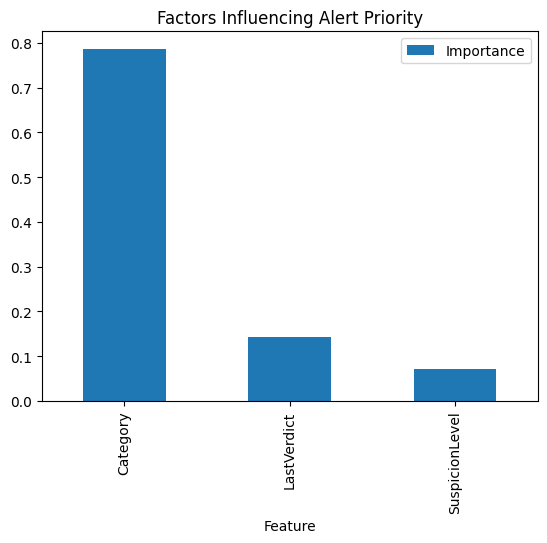

In [23]:
importance.plot(
    x="Feature",
    y="Importance",
    kind="bar"
)

plt.title(
    "Factors Influencing Alert Priority"
)

plt.show()

In [24]:
high_priority = data[
    data["Priority"].isin(
        le_priority.transform(
            ["Critical"]
        )
    )
]

print(
    "Total Alerts:",
    len(data)
)

print(
    "Critical Alerts:",
    len(high_priority)
)

Total Alerts: 1527080
Critical Alerts: 548666


In [ ]:
new_alert = pd.DataFrame({
    "Category":[
        le_category.transform(
            ["CredentialAccess"]
        )[0]
    ],
    "SuspicionLevel":[
        le_suspicion.transform(
            ["Suspicious"]
        )[0]
    ],
    "LastVerdict":[
        le_verdict.transform(
            ["Suspicious"]
        )[0]
    ]
})

prediction = model.predict(
    new_alert
)

print(
    "Predicted Priority:",
    le_priority.inverse_transform(
        prediction
    )[0]
)

,failed_logins,malware_score,asset_criticality,privileged_user,priority
0,51,33,4,0,1
1,92,7,1,1,3
2,14,39,4,1,1
3,71,82,4,1,0
4,60,41,1,1,3
